### **라이브러리 로드**

In [33]:
# 데이터 처리
import pandas as pd
import numpy as np
from IPython.display import display

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# 통계 검정
import scipy
from scipy.stats import chi2_contingency  # 카이제곱 검정
from scipy.stats import spearmanr         # 스피어만 상관계수
from scipy.stats import PermutationMethod # Monte Carlo 시뮬레이션
from scipy.stats import fisher_exact # Fisher's exact

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 데이터프레임 출력 제한 해제
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

---
### **데이터 로드**

In [34]:
# IT 롱폼에서 성공으로 분류된 영상 분류 결과
df_success_video = pd.read_csv("../../../data/results/main_dataset/롱폼 영상(+콘텐츠 분류 정보)/it_longform_success_data_with_classified.csv", encoding='utf-8')

# IT 롱폼에서 실패로 분류된 영상 분류 결과
df_fail_video = pd.read_csv("../../../data/results/main_dataset/롱폼 영상(+콘텐츠 분류 정보)/it_longform_fail_data_with_classified.csv", encoding='utf-8')

# IT 롱폼에서 성공으로 분류된 영상의 댓글 감성 분석 결과
df_success_comment = pd.read_csv("../../../data/results/main_dataset/댓글(필터링+감성분석 정보)/sentiment_filtered_cleaned_it_longform_success_comment.csv", encoding='utf-8')

# IT 롱폼에서 실패으로 분류된 영상의 댓글 감성 분석 결과
df_fail_comment = pd.read_csv("../../../data/results/main_dataset/댓글(필터링+감성분석 정보)/sentiment_filtered_cleaned_it_longform_fail_comment.csv", encoding='utf-8')

In [35]:
# 데이터 로드 결과 확인
print("성공 영상 분류 결과:", df_success_video.columns.tolist())
print("실패 영상 분류 결과:", df_fail_video.columns.tolist())
print("성공 영상의 댓글 감성 분석 결과:", df_success_comment.columns.tolist())
print("실패 영상의 댓글 감성 분석 결과:", df_fail_comment.columns.tolist())

성공 영상 분류 결과: ['video_id', 'title', 'channel_id', '채널명', 'description', '업로드일시', 'tags', '조회수', '좋아요수', '댓글수', '영상길이(초)', 'definition', 'license', 'embeddable', 'has_paid_product_placement', 'thumbnail', 'caption', 'final_url', 'instream_type', 'channel_handle', 'channel_tier', '구독자수', 'domain', 'description_missing_flag', 'tags_missing_flag', '참여율(ER)', '조회수 대비 좋아요율', '조회수 대비 댓글률', 'wei', 'description_length', 'category_name', 'upload_year', 'upload_month', 'upload_dayofweek', 'upload_hour', 'tags_count', 'upload_quarter', 'upload_ym_quarter', 'upload_ymd', '경과일수', '도달률(RR)', '일평균 조회수', 'RR_백분위', 'ER_백분위', 'score1', '조회수성과', '좋아요성과', '댓글성과', '조회수성과_상위1%', '조회수성과_상위5%', '좋아요성과_상위1%', '좋아요성과_상위5%', '댓글성과_상위1%', '댓글성과_상위5%', 'score2', 'grade', 'cls_domain', 'cls_content_type', 'cls_marketing_purpose', 'cls_cta_type', 'cls_is_series', 'cls_is_collaboration', 'cls_reason']
실패 영상 분류 결과: ['video_id', 'title', 'channel_id', '채널명', 'description', '업로드일시', 'tags', '조회수', '좋아요수', '댓글수', '영상길이(초)'

In [36]:
# 데이터프레임 확인
display(df_success_video.head(1))
display(df_fail_video.head(1))
display(df_success_comment.head(1))
display(df_fail_comment.head(1))

,video_id,title,channel_id,채널명,description,업로드일시,tags,조회수,좋아요수,댓글수,영상길이(초),definition,license,embeddable,has_paid_product_placement,thumbnail,caption,final_url,instream_type,channel_handle,channel_tier,구독자수,domain,description_missing_flag,tags_missing_flag,참여율(ER),조회수 대비 좋아요율,조회수 대비 댓글률,wei,description_length,category_name,upload_year,upload_month,upload_dayofweek,upload_hour,tags_count,upload_quarter,upload_ym_quarter,upload_ymd,경과일수,도달률(RR),일평균 조회수,RR_백분위,ER_백분위,score1,조회수성과,좋아요성과,댓글성과,조회수성과_상위1%,조회수성과_상위5%,좋아요성과_상위1%,좋아요성과_상위5%,댓글성과_상위1%,댓글성과_상위5%,score2,grade,cls_domain,cls_content_type,cls_marketing_purpose,cls_cta_type,cls_is_series,cls_is_collaboration,cls_reason
0,HPHOqocPZXg,[Simple. Lab] EP2. 이런 기능이 생기면 어때요?,UCp3BSINVC7Ggj4kChEUiy7Q,LG유플러스 (LG Uplus),"#유플러스 #LG유플러스 #심플랩 #U+one #부스터스\n\n📡여러분의 소중한 통신 아이디어를 'Simple. Lab(심플랩)'을 통해 보내주시면\n모아서 유플러스에 직접 전달해드립니다!\n\n✍️ 참여 방법 (간단!)\n[U+one 앱] → [고객지원] → [Simple. Lab – 아이디어 제안]\n통해서 통신 관련 아이디어를 자유롭게 제출해 주세요!\n\n📮 이렇게 모인 심플랩 아이디어는\n유플러스 공식 크리에이터 부스터스가\n👉 1기 김학영 / 2기 정대철\n재밌고 솔직하게 사연으로 읽어드립니다!\n\n💬#EVENT 댓글 이벤트 안내\n해당 영상을 시청한 후, 여러분의 일상에서 'Simple. Lab(심플랩)'이 어떤 역할을 했으면 좋겠는지 댓글로 편하게 남겨주세요!\n\n✨이벤트 경품\n메가박스 영화관람권 2매 (10명) \n복잡한 일상도 잠시, 심플한 여유를 즐겨보세요!\n\n✨이벤트 기간\n참여기간: 2월 13일(금) ~ 2월 27일(금)\n\n당첨자 발표: 3월 6일(금) LG유플러스 유튜브 '게시물'을 통해 발표\n\n여러분이 심플랩으로 주신 아이디어는 잘 검토하여 더 나은 통신생활을 만들어보도록 노력해보겠습니다👀✨\n\n✅ LG유플러스 공식유튜브 구독하기: https://bit.ly/3w6LvO7",2026-02-13 06:29:46,"#유플러스, #LG유플러스, #심플랩, #U+one, #부스터스",243285,373.0,673.0,701.0,hd,youtube,True,False,https://i.ytimg.com/vi/HPHOqocPZXg/hqdefault.jpg,False,https://www.youtube.com/watch?v=HPHOqocPZXg,일반영상,@lguplus,mega,660000,IT,0,0,0.357638,0.153318,0.27663,0.706579,605,예능/오락 콘텐츠,2026,2,금요일,6,5,1,2026-Q1,2026-02-13,73,0.005037,3332.671233,0.948712,0.214023,0.901317,2.830492,0.326117,1.820148,0,0,0,0,0,0,1.509343,성공,IT,웹예능,고객유입,이벤트참여,True,False,"채널이 통신사(IT)이며, 제목에 EP2가 포함되어 시리즈물임을 알 수 있습니다. 부스터스라는 크리에이터들이 아이디어를 소개하는 형식이 웹예능에 해당합니다. 설명란에 댓글 이벤트 안내가 명시되어 있어 마케팅 목적은 고객유입, CTA는 이벤트참여로 분류했습니다."


,video_id,title,channel_id,채널명,description,업로드일시,tags,조회수,좋아요수,댓글수,영상길이(초),definition,license,embeddable,has_paid_product_placement,thumbnail,caption,final_url,instream_type,channel_handle,channel_tier,구독자수,domain,description_missing_flag,tags_missing_flag,참여율(ER),조회수 대비 좋아요율,조회수 대비 댓글률,wei,description_length,category_name,upload_year,upload_month,upload_dayofweek,upload_hour,tags_count,upload_quarter,upload_ym_quarter,upload_ymd,경과일수,도달률(RR),일평균 조회수,RR_백분위,ER_백분위,score1,조회수성과,좋아요성과,댓글성과,조회수성과_상위1%,조회수성과_상위5%,좋아요성과_상위1%,좋아요성과_상위5%,댓글성과_상위1%,댓글성과_상위5%,score2,grade,cls_domain,cls_content_type,cls_marketing_purpose,cls_cta_type,cls_is_series,cls_is_collaboration,cls_reason
0,7lBxgT0esa8,"[Futurize 2025: Security Forum] Gen AI 시대의 보안 전략, AlphaKey",UCp3BSINVC7Ggj4kChEUiy7Q,LG유플러스 (LG Uplus),"생성형 AI 시대, 기업의 보안 관리가 더욱 중요해집니다.​\n​\n지난 9월에 진행한 [Futurize 2025] 행사에서​\nLG유플러스의 AlphaKey로 시작하는​\n기업의 보안 전략에 대한 인사이트를 나누었습니다.​\n\n통합 계정 관리 서비스인 AlphaKey에 대한 소개와​\n구체적인 적용 전략까지, 이번 영상을 통해 만나보세요. ​\n\n🔐AlphaKey 상담 신청: https://bit.ly/4oKsvkn\n🔐AlphaKey 무료체험 신청: https://bit.ly/4r7UAUr\n🔐행사 Full ver. 영상 보러가기: https://bit.ly/4piO3V9\n\n#LG유플러스 #Futurize2025 #SecurityForum​ \n#보안전략 #비즈니스보안 #Alphakey\n\n✅ LG유플러스 공식유튜브 구독하기: https://bit.ly/3w6LvO7",2025-12-22 07:11:45,"#lg유플러스, #유플러스, #유플러스B2B, #lguplus_enterprise, #Futurize2025, #SecurityForum, #보안전략, #비즈니스보안, #기업보안, #PQC, #Alphakey, #IDaaS, #데이터보호, #제로트러스트, #기업계정관리",180,1.0,0.0,936.0,hd,youtube,True,False,https://i.ytimg.com/vi/7lBxgT0esa8/hqdefault.jpg,False,https://www.youtube.com/watch?v=7lBxgT0esa8,일반영상,@lguplus,mega,660000,IT,0,0,0.441833,0.555556,0.0,0.555556,425,과학/기술,2025,12,월요일,7,15,4,2025-Q4,2025-12-22,126,0.000002,1.428571,0.036789,0.272993,0.052026,0.369029,0.982654,0.0,0,0,0,0,0,0,0.501694,실패,IT,기술설명,제품홍보,구매유도,False,False,"LG유플러스의 B2B 보안 서비스인 'AlphaKey'의 기능과 전략을 소개하는 영상으로, 기술적 내용을 다루고 있으며 설명란에 상담 및 무료체험 신청 링크(구매유도)가 명시되어 있어 제품홍보 목적이 뚜렷함."


,comment_id,video_id,sentiment,is_korean,is_event,reason
0,UgxlzXr3KhBMpQMWQAN4AaABAg,HPHOqocPZXg,긍정,True,False,심플랩의 콘텐츠를 통해 더 나은 모습으로 성장하고 싶다는 기대와 긍정적인 다짐이 담겨 있습니다.


,comment_id,video_id,sentiment,is_korean,is_event,reason
0,UgwGQ_l0W2aWiIeyqd54AaABAg,DSP-1N5lIf0,중립,True,False,해당 댓글은 서비스 이용을 위한 공식 안내 및 정보 제공을 목적으로 작성된 홍보성 댓글로 판단됩니다.


---
### **데이터 전처리**

In [37]:
# ========================================
# [전처리 1] 필요한 컬럼만 선택
# ========================================

# [역할] 분석에 필요한 컬럼만 추출하여 데이터 크기 축소
# [근거] 불필요한 컬럼을 제거하여 메모리 효율화 및 가독성 향상

VIDEO_COLS = [
    'video_id', '조회수', '좋아요수', '댓글수', '영상길이(초)',
    '구독자수', '참여율(ER)', '일평균 조회수', 'score1', 'score2', 'grade',
    'cls_domain', 'cls_content_type', 'cls_marketing_purpose',
    'cls_cta_type', 'cls_is_series', 'cls_is_collaboration'
]

COMMENT_COLS = ['comment_id', 'video_id', 'sentiment', 'is_korean', 'is_event']

df_success_video = df_success_video[VIDEO_COLS]
df_fail_video = df_fail_video[VIDEO_COLS]
df_success_comment = df_success_comment[COMMENT_COLS]
df_fail_comment = df_fail_comment[COMMENT_COLS]

In [38]:
# ========================================
# [전처리 2] 성공/실패 데이터 통합
# ========================================

# [역할] 성공/실패 영상 분류 결과와 댓글 감성 분석 결과를 각각 하나의 데이터프레임으로 통합
# [근거] 이후 분석에서 성공/실패를 grade 컬럼으로 구분하므로 하나로 합치는 게 효율적

df_video = pd.concat([df_success_video, df_fail_video], ignore_index=True)
df_comment_1 = pd.concat([df_success_comment, df_fail_comment], ignore_index=True)

print(f"영상 데이터: {len(df_video)}개") # 794개
print(f"댓글 데이터: {len(df_comment_1)}개") # 47305개

영상 데이터: 794개
댓글 데이터: 47305개


In [39]:
# ========================================
# [전처리 3] 이벤트 참여 댓글 제거
# ========================================

# [역할] is_event=True인 댓글 제거
# [근거] 이벤트 참여 목적의 댓글은 영상 콘텐츠에 대한 반응이 아니므로
#        감성 비율을 왜곡할 수 있음

before = len(df_comment_1)
df_comment_2 = df_comment_1[df_comment_1['is_event'] == False]
print(f"이벤트 댓글 제거: {before - len(df_comment_2)}개 제거 → {len(df_comment_2)}개 남음") # 8000개 제거 → 39305개 남음

이벤트 댓글 제거: 8000개 제거 → 39305개 남음


In [40]:
# ========================================
# [전처리 4] 외국어 댓글 제거
# ========================================

# [역할] is_korean=False인 댓글 제거
# [근거] 외국어 댓글은 뉘앙스 파악의 한계로 감성 분류 신뢰도가 낮을 수 있음.
#        분석 대상이 한국 브랜드의 유튜브 채널이므로 한국어 댓글만 분석

before = len(df_comment_2)
df_comment = df_comment_2[df_comment_2['is_korean'] == True]
print(f"외국어 댓글 제거: {before - len(df_comment)}개 제거 → {len(df_comment)}개 남음") # 796개 제거 → 38509개 남음

외국어 댓글 제거: 796개 제거 → 38509개 남음


In [41]:
# ========================================
# [전처리 5] video_id 기준으로 merge
# ========================================

# [역할] 영상 분류 정보에 댓글 감성 분석 결과를 결합
# [근거] 영상 데이터를 기준으로 merge하여 영상 분류 정보를 중심으로 댓글 데이터를 연결
# [작업] how='inner'로 양쪽 데이터에 모두 존재하는 video_id만 결합
#        → 댓글이 없는 영상은 제외됨

df = pd.merge(df_video, df_comment, on='video_id', how='inner')

print(f"merge 후 데이터: {len(df)}개")
print(f"NaN 현황:\n{df.isna().sum()}")

merge 후 데이터: 38509개
NaN 현황:
video_id                 0
조회수                      0
좋아요수                     0
댓글수                      0
영상길이(초)                  0
구독자수                     0
참여율(ER)                  0
일평균 조회수                  0
score1                   0
score2                   0
grade                    0
cls_domain               0
cls_content_type         0
cls_marketing_purpose    0
cls_cta_type             0
cls_is_series            0
cls_is_collaboration     0
comment_id               0
sentiment                0
is_korean                0
is_event                 0
dtype: int64


In [42]:
# ========================================
# [전처리 6] 최종 데이터 확인
# ========================================

# [역할] 전처리 완료 후 데이터 상태 최종 점검
# [근거] 행/열 수, 샘플 데이터를 확인하여 전처리 결과 검증

print(f"최종 데이터: {len(df)}행 / {len(df.columns)}열") # 38509행 / 21열
print(f"\n[감성 분포]")
print(df['sentiment'].value_counts())
print(f"\n[성공/실패 분포]")
print(df['grade'].value_counts())
display(df.head(3))

최종 데이터: 38509행 / 21열

[감성 분포]
sentiment
긍정    33659
부정     2611
중립     2239
Name: count, dtype: int64

[성공/실패 분포]
grade
성공    38453
실패       56
Name: count, dtype: int64


,video_id,조회수,좋아요수,댓글수,영상길이(초),구독자수,참여율(ER),일평균 조회수,score1,score2,grade,cls_domain,cls_content_type,cls_marketing_purpose,cls_cta_type,cls_is_series,cls_is_collaboration,comment_id,sentiment,is_korean,is_event
0,HPHOqocPZXg,243285,373.0,673.0,701.0,660000,0.357638,3332.671233,0.901317,1.509343,성공,IT,웹예능,고객유입,이벤트참여,True,False,UgxlzXr3KhBMpQMWQAN4AaABAg,긍정,True,False
1,HPHOqocPZXg,243285,373.0,673.0,701.0,660000,0.357638,3332.671233,0.901317,1.509343,성공,IT,웹예능,고객유입,이벤트참여,True,False,Ugw4mTEGpRBsjaS43TF4AaABAg,긍정,True,False
2,HPHOqocPZXg,243285,373.0,673.0,701.0,660000,0.357638,3332.671233,0.901317,1.509343,성공,IT,웹예능,고객유입,이벤트참여,True,False,UgwUtr1J5oOvvyOkV0p4AaABAg,긍정,True,False


In [43]:
# ========================================
# [전처리 6] 성공 영상 댓글만 필터링
# ========================================

# [역할] grade=성공인 댓글만 분석 대상으로 설정
# [근거] 실패 영상 댓글(56개)이 너무 적어 통계 검정 신뢰도를 보장하기 어려움
#        성공 영상 댓글만 분석하여 긍정 반응을 이끌어내는 콘텐츠 특성 파악에 집중
# [작업] grade == '성공' 조건으로 필터링

print(f"[필터링 전 성공/실패 분포]")
grade_counts = df['grade'].value_counts()
grade_pct = df['grade'].value_counts(normalize=True) * 100
for grade in grade_counts.index:
    print(f" {grade}: {grade_counts[grade]}개 ({grade_pct[grade]:.1f}%)")

before = len(df)
df = df[df['grade'] == '성공']
print(f"\n성공 영상 필터링: {before - len(df)}개 제거 → {len(df)}개 남음")

[필터링 전 성공/실패 분포]
 성공: 38453개 (99.9%)
 실패: 56개 (0.1%)

성공 영상 필터링: 56개 제거 → 38453개 남음


In [44]:
# ========================================
# [전처리 7] 최종 데이터 확인
# ========================================

# [역할] 전처리 완료 후 데이터 상태 최종 점검
# [작업] 행/열 수, 감성 분포, 샘플 데이터 확인

print(f"최종 데이터: {len(df)}행 / {len(df.columns)}열")
print(f"\n[감성 분포]")
sentiment_counts = df['sentiment'].value_counts()
sentiment_pct = df['sentiment'].value_counts(normalize=True) * 100
for sentiment in sentiment_counts.index:
    print(f" {sentiment}: {sentiment_counts[sentiment]}개 ({sentiment_pct[sentiment]:.1f}%)")

최종 데이터: 38453행 / 21열

[감성 분포]
 긍정: 33659개 (87.5%)
 부정: 2608개 (6.8%)
 중립: 2186개 (5.7%)


---
### **통계 검정**

<성공으로 분류된 영상에 대해 분석하기로 선택한 이유>

현재 보유한 IT 롱폼 데이터에서 성공 영상 댓글은 38,453개, 실패 영상 댓글은 56개로 극심한 불균형이 존재한다. 실패 영상 댓글 수가 너무 적어 통계 검정 결과의 신뢰도를 보장하기 어렵기 때문에, 성공 영상 댓글만을 분석 대상으로 설정했다. 
이와 같은 방향으로 분석한 뒤, "성공한 영상에서 어떤 콘텐츠 특성이 긍정적인 반응을 이끌어내는가"에 집중하여 동영상 제작 가이드 도출에 활용하면 좋을 것 같다.

##### **1단계: Cochran's rule 확인**
아래 두 조건을 모두 충족해야 카이제곱 검정을 적용할 수 있다.
- 기대빈도 1 미만인 셀이 없어야 함
- 기대빈도 5 미만인 셀의 비율이 20% 이하여야 함

두 조건 중 하나라도 위반 시 → Monte Carlo 시뮬레이션으로 대체 예정

##### **2단계: 카이제곱 검정 vs Monte Carlo 시뮬레이션**

| 구분 | 카이제곱 검정 | Monte Carlo 시뮬레이션 |
|---|---|---|
| 적용 조건 | Cochran's rule 충족 | Cochran's rule 위반 |
| 데이터 규모 | 대규모 | 대규모 |
| p-value 방식 | 이론적 분포 기반 | 시뮬레이션 기반 추정 |
| 계산 비용 | 낮음 | 높음 |

<p-value를 구하는 방법의 차이>
카이제곱 검정 → 카이제곱 통계량을 이론적 분포(카이제곱 분포)에 대입해서 p-value 계산
Monte Carlo → 동일한 카이제곱 통계량을 시뮬레이션 결과와 비교해서 p-value 추정

##### **3단계: 크래머 V (효과 크기)**
카이제곱/Monte Carlo 검정 결과가 유의미한 경우에만 적용한다.
카이제곱 통계량을 기반으로 계산하므로 두 검정 방법 모두 동일하게 적용 가능하다.
공식: `√(χ² / (N · min(r−1, c−1)))`
효과 크기 기준은 `df*(= min(r−1, c−1))`에 따라 다르게 적용한다.

| df* | 매우 작음 | 작음 | 중간 | 큼 |
|---|---|---|---|---|
| 1 | ~0.10 | 0.10~0.30 | 0.30~0.50 | 0.50~ |
| 2 | ~0.07 | 0.07~0.21 | 0.21~0.35 | 0.35~ |
| 3 | ~0.06 | 0.06~0.17 | 0.17~0.29 | 0.29~ |
| 4 | ~0.05 | 0.05~0.15 | 0.15~0.25 | 0.25~ |
| 5 | ~0.04 | 0.04~0.13 | 0.13~0.22 | 0.22~ |

##### **4단계: 조정된 잔차 사후검정**
카이제곱/Monte Carlo 검정 결과가 유의미한 경우에만 수행한다.
어떤 셀이 기대보다 유의미하게 많거나 적은지 파악한다.
- 기준: |조정된 잔차| > 1.96 (95% 신뢰수준)
- 양수: 기대보다 많음 (↑)
- 음수: 기대보다 적음 (↓)

In [45]:
# ========================================
# 통계 검정 함수 정의
# ========================================

# [역할] 범주형 변수와 sentiment 간의 관계를 통계적으로 검정
# [작업] Cochran's rule 확인 → 카이제곱 or Monte Carlo 시뮬레이션
#        → 크래머 V → 조정된 잔차 사후검정

def chi2_test(df, col, target='sentiment', alpha=0.05, n_simulations=9999):
    """
    Parameters
    ----------
    df            : 분석 데이터프레임
    col           : 검정할 범주형 변수 컬럼명
    target        : 감성 컬럼명 (기본값: 'sentiment')
    alpha         : 유의수준 (기본값: 0.05)
    n_simulations : Monte Carlo 시뮬레이션 횟수 (기본값: 9999)
    """

    print(f"\n{'='*60}")
    print(f"[{col}] × [{target}] 검정")
    print(f"{'='*60}")

    # ── 1단계: 교차표 및 기대빈도 계산 ──────────────────────
    # [작업] pd.crosstab으로 교차표 생성
    #        chi2_contingency로 카이제곱 통계량, p-value, 자유도, 기대빈도 계산
    contingency_table = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # ── 2단계: Cochran's rule 확인 ───────────────────────────
    # [작업] 조건 1: 기대빈도 1 미만인 셀이 없어야 함
    #       조건 2: 기대빈도 5 미만인 셀의 비율이 20% 이하여야 함
    #       -> 두 조건 중 하나라도 위반 시 Monte Carlo 시뮬레이션으로 바꿔서 수행
    total_cells = expected.size
    zero_cells = (expected < 1).sum()
    low_cells = (expected < 5).sum()
    low_cells_pct = low_cells / total_cells * 100

    print(f"\n[Cochran's rule 확인]")
    print(f"  전체 셀 수: {total_cells}")
    print(f"  기대빈도 1 미만 셀 수: {zero_cells}")
    print(f"  기대빈도 5 미만 셀 수: {low_cells} ({low_cells_pct:.1f}%)")

    # True: Monte Carlo 시뮬레이션 사용 / False: 카이제곱 검정 사용
    use_monte_carlo = (zero_cells > 0) or (low_cells_pct > 20)

    if use_monte_carlo:
        print(f"  ⚠️ Cochran's rule 위반 → Monte Carlo 시뮬레이션으로 대체")
    else:
        print(f"  ✅ Cochran's rule 충족 → 카이제곱 검정 진행")

    # ── 3단계: 카이제곱 검정 or Monte Carlo 시뮬레이션 ────────
    if use_monte_carlo:
        # [작업] scipy의 PermutationMethod를 사용하여 행/열 합계를 고정한 채
        #        n_simulations번 랜덤 교차표를 생성하여 p-value를 추정
        #        correction=False: Yates 연속성 보정은 Monte Carlo와 함께 사용 불가
        #        random_state=42: 재현 가능한 결과를 위해 시드 고정
        method = PermutationMethod(n_resamples=n_simulations, random_state=42)
        result = chi2_contingency(contingency_table, correction=False, method=method)
        chi2 = result.statistic
        p_val = result.pvalue

        print(f"\n[Monte Carlo 시뮬레이션 결과] (n={n_simulations:,})")
        print(f"  χ²     : {chi2:.4f}")
        print(f"  p-value: {p_val:.4f}")
        print(f"  자유도  : {dof}") # 자유도가 클수록 더 많은 범주 조합을 검정한다는 의미 
                                   # -> 카이제곱 통계량이 같아도 자유도에 따라 p-value가 달라진다고 함
    else:
        # [작업] p를 p_val로 명시적으로 할당하여 이후 코드에서 일관되게 사용
        p_val = p
        print(f"\n[카이제곱 검정 결과]")
        print(f"  χ²     : {chi2:.4f}")
        print(f"  p-value: {p_val:.4f}")
        print(f"  자유도  : {dof}")

    if p_val < alpha:
        print(f"  ✅ 유의미한 관계 있음 (p < {alpha})")
    else:
        print(f"  ❌ 유의미한 관계 없음 (p >= {alpha})")
        return None

    # ── 4단계: 크래머 V (효과 크기) ──────────────────────────
    # [작업] df* = min(r-1, c-1)에 따라 효과 크기 기준이 달라짐
    #        공식: √(χ² / (N · df*))
    #        df*별 효과 크기 기준은 Cohen(1988)의 w값(0.10, 0.30, 0.50)을
    #        V = w / √(df*) 공식에 대입하여 계산
    n = contingency_table.values.sum() # 전체 댓글 수
    df_star  = min(contingency_table.shape) - 1
    cramer_v = np.sqrt(chi2 / (n * df_star))

    small = 0.10 / np.sqrt(df_star)
    medium = 0.30 / np.sqrt(df_star)
    large = 0.50 / np.sqrt(df_star)

    print(f"\n[크래머 V (효과 크기)]")
    print(f"  df*    : {df_star}")
    print(f"  크래머 V: {cramer_v:.4f}")
    if cramer_v < small:
        print(f"  → 효과 매우 작음 ({small:.2f} 미만)")
    elif cramer_v < medium:
        print(f"  → 효과 작음 ({small:.2f} 이상 {medium:.2f} 미만)")
    elif cramer_v < large:
        print(f"  → 효과 중간 ({medium:.2f} 이상 {large:.2f} 미만)")
    else:
        print(f"  → 효과 큼 ({large:.2f} 이상)")

    # ── 5단계: 조정된 잔차 사후검정 ──────────────────────────
    # [작업] 조정된 잔차 = (관측빈도 - 기대빈도) / 표준오차
    #        표준오차 = sqrt(기대빈도 × (1 - 행비율) × (1 - 열비율))
    #        |조정된 잔차| > 1.96이면 유의미한 셀 (95% 신뢰수준)
    observed = contingency_table.values
    row_sums = observed.sum(axis=1, keepdims=True)
    col_sums = observed.sum(axis=0, keepdims=True)
    total = observed.sum()

    std_err = np.sqrt(expected * (1 - row_sums / total) * (1 - col_sums / total))
    adjusted_resid = (observed - expected) / std_err

    df_resid = pd.DataFrame(
        adjusted_resid,
        index=contingency_table.index,
        columns=contingency_table.columns
    ).round(2)

    print(f"\n[조정된 잔차 사후검정]")
    print(f"  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)")
    display(df_resid)

    print(f"\n[유의미한 셀 요약]")
    for row in df_resid.index:
        for col_name in df_resid.columns:
            resid = df_resid.loc[row, col_name]
            if abs(resid) > 1.96:
                direction = "많음 (↑)" if resid > 0 else "적음 (↓)"
                print(f"  {row} × {col_name}: {resid} → 기대보다 {direction}")

    return {
        'chi2' : chi2,
        'p-value' : p_val,
        'df_star' : df_star,
        'cramer_v' : cramer_v,
        'use_monte_carlo': use_monte_carlo,
        'residuals' : df_resid
    }

In [46]:
# ========================================
# 카이제곱 검정 실행
# ========================================

# [역할] 롱폼 분석 항목의 범주형 변수와 sentiment 간의 관계 검정
# [작업] 각 컬럼에 대해 chi2_test() 함수 실행

CATEGORICAL_COLS = [
    'cls_content_type',         # 영상 유형
    'cls_marketing_purpose',    # 영상 업로드 목적
    'cls_cta_type',             # CTA 타입
    'cls_is_series',            # 시리즈물 여부
    'cls_is_collaboration'      # 콜라보 여부
]

results = {}
for col in CATEGORICAL_COLS:
    results[col] = chi2_test(df, col)


[cls_content_type] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 36
  기대빈도 1 미만 셀 수: 2
  기대빈도 5 미만 셀 수: 5 (13.9%)
  ⚠️ Cochran's rule 위반 → Monte Carlo 시뮬레이션으로 대체

[Monte Carlo 시뮬레이션 결과] (n=9,999)
  χ²     : 1171.2024
  p-value: 0.0001
  자유도  : 22
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 2
  크래머 V: 0.1234
  → 효과 작음 (0.07 이상 0.21 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)


sentiment,긍정,부정,중립
cls_content_type,,,
광고/CF,-1.61,2.43,-0.35
기술설명,2.18,-0.19,-2.90
기타,-2.82,2.32,1.51
브이로그,6.94,-5.82,-3.58
시설소개,-3.24,1.42,3.09
에피소드소개,1.87,1.27,-4.04
웹드라마,9.74,-7.04,-6.25
웹예능,-8.01,3.85,7.25
이벤트/행사,9.75,-7.85,-5.39



[유의미한 셀 요약]
  광고/CF × 부정: 2.43 → 기대보다 많음 (↑)
  기술설명 × 긍정: 2.18 → 기대보다 많음 (↑)
  기술설명 × 중립: -2.9 → 기대보다 적음 (↓)
  기타 × 긍정: -2.82 → 기대보다 적음 (↓)
  기타 × 부정: 2.32 → 기대보다 많음 (↑)
  브이로그 × 긍정: 6.94 → 기대보다 많음 (↑)
  브이로그 × 부정: -5.82 → 기대보다 적음 (↓)
  브이로그 × 중립: -3.58 → 기대보다 적음 (↓)
  시설소개 × 긍정: -3.24 → 기대보다 적음 (↓)
  시설소개 × 중립: 3.09 → 기대보다 많음 (↑)
  에피소드소개 × 중립: -4.04 → 기대보다 적음 (↓)
  웹드라마 × 긍정: 9.74 → 기대보다 많음 (↑)
  웹드라마 × 부정: -7.04 → 기대보다 적음 (↓)
  웹드라마 × 중립: -6.25 → 기대보다 적음 (↓)
  웹예능 × 긍정: -8.01 → 기대보다 적음 (↓)
  웹예능 × 부정: 3.85 → 기대보다 많음 (↑)
  웹예능 × 중립: 7.25 → 기대보다 많음 (↑)
  이벤트/행사 × 긍정: 9.75 → 기대보다 많음 (↑)
  이벤트/행사 × 부정: -7.85 → 기대보다 적음 (↓)
  이벤트/행사 × 중립: -5.39 → 기대보다 적음 (↓)
  인터뷰 × 긍정: -10.16 → 기대보다 적음 (↓)
  인터뷰 × 부정: 5.54 → 기대보다 많음 (↑)
  인터뷰 × 중립: 8.48 → 기대보다 많음 (↑)
  제품리뷰 × 긍정: 3.78 → 기대보다 많음 (↑)
  제품리뷰 × 부정: -4.19 → 기대보다 적음 (↓)
  튜토리얼 × 긍정: -23.79 → 기대보다 적음 (↓)
  튜토리얼 × 부정: 26.23 → 기대보다 많음 (↑)
  튜토리얼 × 중립: 5.45 → 기대보다 많음 (↑)

[cls_marketing_purpose] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 27


sentiment,긍정,부정,중립
cls_marketing_purpose,,,
고객유입,-2.88,11.69,-8.58
고객유지,5.27,-5.62,-1.42
기업이미지,16.58,-10.79,-11.93
브랜드캠페인,-8.36,5.14,6.34
사회공헌/환경,2.85,-1.46,-2.48
서비스활용,-25.21,14.67,20.03
정보제공,-7.72,5.38,5.17
제품홍보,13.30,-10.00,-8.12
채용,-4.55,-0.93,7.50



[유의미한 셀 요약]
  고객유입 × 긍정: -2.88 → 기대보다 적음 (↓)
  고객유입 × 부정: 11.69 → 기대보다 많음 (↑)
  고객유입 × 중립: -8.58 → 기대보다 적음 (↓)
  고객유지 × 긍정: 5.27 → 기대보다 많음 (↑)
  고객유지 × 부정: -5.62 → 기대보다 적음 (↓)
  기업이미지 × 긍정: 16.58 → 기대보다 많음 (↑)
  기업이미지 × 부정: -10.79 → 기대보다 적음 (↓)
  기업이미지 × 중립: -11.93 → 기대보다 적음 (↓)
  브랜드캠페인 × 긍정: -8.36 → 기대보다 적음 (↓)
  브랜드캠페인 × 부정: 5.14 → 기대보다 많음 (↑)
  브랜드캠페인 × 중립: 6.34 → 기대보다 많음 (↑)
  사회공헌/환경 × 긍정: 2.85 → 기대보다 많음 (↑)
  사회공헌/환경 × 중립: -2.48 → 기대보다 적음 (↓)
  서비스활용 × 긍정: -25.21 → 기대보다 적음 (↓)
  서비스활용 × 부정: 14.67 → 기대보다 많음 (↑)
  서비스활용 × 중립: 20.03 → 기대보다 많음 (↑)
  정보제공 × 긍정: -7.72 → 기대보다 적음 (↓)
  정보제공 × 부정: 5.38 → 기대보다 많음 (↑)
  정보제공 × 중립: 5.17 → 기대보다 많음 (↑)
  제품홍보 × 긍정: 13.3 → 기대보다 많음 (↑)
  제품홍보 × 부정: -10.0 → 기대보다 적음 (↓)
  제품홍보 × 중립: -8.12 → 기대보다 적음 (↓)
  채용 × 긍정: -4.55 → 기대보다 적음 (↓)
  채용 × 중립: 7.5 → 기대보다 많음 (↑)

[cls_cta_type] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 21
  기대빈도 1 미만 셀 수: 2
  기대빈도 5 미만 셀 수: 5 (23.8%)
  ⚠️ Cochran's rule 위반 → Monte Carlo 시뮬레이션으로 대체

[Monte Carlo 시뮬레이션 결과] (n

...


[유의미한 셀 요약]
  구독유도 × 긍정: -19.39 → 기대보다 적음 (↓)
  구독유도 × 부정: 24.49 → 기대보다 많음 (↑)
  구매유도 × 긍정: 5.0 → 기대보다 많음 (↑)
  구매유도 × 부정: -2.1 → 기대보다 적음 (↓)
  구매유도 × 중립: -4.85 → 기대보다 적음 (↓)
  기타 × 긍정: 13.92 → 기대보다 많음 (↑)
  기타 × 부정: -13.69 → 기대보다 적음 (↓)
  기타 × 중립: -5.0 → 기대보다 적음 (↓)
  정보탐색 × 긍정: -6.31 → 기대보다 적음 (↓)
  정보탐색 × 부정: 3.57 → 기대보다 많음 (↑)
  정보탐색 × 중립: 5.12 → 기대보다 많음 (↑)

[cls_is_series] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 6
  기대빈도 1 미만 셀 수: 0
  기대빈도 5 미만 셀 수: 0 (0.0%)
  ✅ Cochran's rule 충족 → 카이제곱 검정 진행

[카이제곱 검정 결과]
  χ²     : 186.1173
  p-value: 0.0000
  자유도  : 2
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 1
  크래머 V: 0.0696
  → 효과 매우 작음 (0.10 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)


sentiment,긍정,부정,중립
cls_is_series,,,
False,-13.45,11.2,7.04
True,13.45,-11.2,-7.04



[유의미한 셀 요약]
  False × 긍정: -13.45 → 기대보다 적음 (↓)
  False × 부정: 11.2 → 기대보다 많음 (↑)
  False × 중립: 7.04 → 기대보다 많음 (↑)
  True × 긍정: 13.45 → 기대보다 많음 (↑)
  True × 부정: -11.2 → 기대보다 적음 (↓)
  True × 중립: -7.04 → 기대보다 적음 (↓)

[cls_is_collaboration] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 6
  기대빈도 1 미만 셀 수: 0
  기대빈도 5 미만 셀 수: 0 (0.0%)
  ✅ Cochran's rule 충족 → 카이제곱 검정 진행

[카이제곱 검정 결과]
  χ²     : 27.5882
  p-value: 0.0000
  자유도  : 2
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 1
  크래머 V: 0.0268
  → 효과 매우 작음 (0.10 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)


sentiment,긍정,부정,중립
cls_is_collaboration,,,
False,-4.33,1.01,5.08
True,4.33,-1.01,-5.08



[유의미한 셀 요약]
  False × 긍정: -4.33 → 기대보다 적음 (↓)
  False × 중립: 5.08 → 기대보다 많음 (↑)
  True × 긍정: 4.33 → 기대보다 많음 (↑)
  True × 중립: -5.08 → 기대보다 적음 (↓)


In [47]:
def visualize_chi2(df, col, result, target='sentiment'):
    """
    Parameters
    ----------
    df     : 분석 데이터프레임
    col    : 검정한 범주형 변수 컬럼명
    result : chi2_test 함수의 반환값 (dict)
    target : 감성 컬럼명 (기본값: 'sentiment')
    """

    if result is None:
        print(f"[{col}] 유의미한 관계가 없어 시각화를 생략합니다.")
        return

    # ── 원본 보호: 함수 진입 시 무조건 copy ─────────────────
    # [근거] bool 타입 여부와 관계없이 함수 내부 수정이
    #        원본 DataFrame에 영향을 주지 않도록 방어적으로 복사
    df1 = df.copy()

    SENTIMENT_ORDER  = ["긍정", "중립", "부정"]
    SENTIMENT_COLORS = {"긍정": "#4CAF50", "중립": "#9E9E9E", "부정": "#F44336"}

    # ── bool 타입 컬럼 문자열 변환 ───────────────────────────
    # [작업] bool 타입 컬럼을 문자열로 변환하여
    #        y축 레이블이 숫자(0, 1)로 나타나는 문제 방지
    # [변경] copy()를 위로 올렸으므로 여기선 조건 분기만 남김
    if df1[col].dtype == bool:
        df1[col] = df1[col].map({True: 'True', False: 'False'})

    # ── 감성 비율 계산 ────────────────────────────────────────
    # [작업] 범주별 감성 비율 계산 후 긍정 비율 기준 오름차순 정렬
    grouped = (
        df1.groupby([col, target])
        .size()
        .reset_index(name='count')
    )
    total_per_group = grouped.groupby(col)['count'].transform('sum')
    grouped['ratio'] = grouped['count'] / total_per_group * 100

    pivot = (
        grouped
        .pivot_table(index=col, columns=target, values='ratio', fill_value=0)
        .reindex(columns=SENTIMENT_ORDER, fill_value=0)
    )

    # [작업] 긍정 비율 기준 오름차순 정렬
    pivot = pivot.sort_values('긍정', ascending=True)

    # ── 그래프 생성 ───────────────────────────────────────────
    n_rows = len(pivot)
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, n_rows * 0.5 + 2)))
    fig.suptitle(f"[{col}] × [{target}] 감성 분석", fontsize=15, fontweight='bold', y=1.01)

    # ── 차트 1: 누적 가로 막대차트 ───────────────────────────
    ax1  = axes[0]
    left = np.zeros(n_rows)

    for sentiment in SENTIMENT_ORDER:
        values = pivot[sentiment].values
        bars   = ax1.barh(
            pivot.index,
            values,
            left=left,
            color=SENTIMENT_COLORS[sentiment],
            label=sentiment,
            height=0.6,
        )
        for bar, val in zip(bars, values):
            if val == 0:
                continue
            x_center = bar.get_x() + bar.get_width() / 2
            y_center = bar.get_y() + bar.get_height() / 2

            if val >= 5:  # 내부 표시
                ax1.text(x_center, y_center, f"{val:.1f}%",
                         ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
            else:          # 외부에 선 연결 (겹침 방지: 위/아래 교차 배치)
                offset_sign = 1 if SENTIMENT_ORDER.index(sentiment) % 2 == 0 else -1
                ax1.annotate(
                    f"{val:.1f}%",
                    xy=(x_center, y_center),
                    xytext=(x_center, y_center + offset_sign * 0.45),
                    arrowprops=dict(arrowstyle="-", color="gray", lw=1),
                    ha='center', va='center',
                    fontsize=8, color='black',
                )
        left += values

    ax1.set_xlim(0, 100)
    ax1.set_xlabel("비율 (%)", fontsize=11)

    # [작업] y축 레이블에 각 범주별 댓글 수 추가
    count_per_group = df1.groupby(col).size()
    new_labels = [f"{idx}\n(n={count_per_group[idx]:,})" for idx in pivot.index]
    ax1.set_yticklabels(new_labels, fontsize=9)

    ax1.set_title("감성 비율 (긍정 비율 기준 정렬)", fontsize=13)
    ax1.legend(loc='lower right', fontsize=10)
    ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
    sns.despine(ax=ax1)

    # ── 차트 2: 조정된 잔차 히트맵 ──────────────────────────
    # [작업] RdYlGn 컬러맵 적용
    #        양수(초록): 해당 감성이 기대보다 자주 나타남
    #        음수(빨강): 해당 감성이 기대보다 적게 나타남
    #        |조정된 잔차| > 1.96인 셀만 유의미한 셀로 해석
    ax2      = axes[1]

    # [작업] bool 인덱스를 문자열로 변환 후 reindex하여 누적 막대차트와 순서 일치
    df1_resid = result['residuals'].copy()
    df1_resid.index = df1_resid.index.astype(str)
    df1_resid = df1_resid.reindex(pivot.index)

    sns.heatmap(
        df1_resid,
        ax=ax2,
        cmap='RdYlGn',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        cbar_kws={'label': '조정된 잔차'}
    )

    ax2.set_title("조정된 잔차 히트맵\n( |잔차| > 1.96, 유의미한 셀)\n(양수: 해당 감성이 기대보다 자주 나타남 / 음수: 해당 감성이 기대보다 적게 나타남)", fontsize=11)
    ax2.set_xlabel("감성", fontsize=11)
    ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()

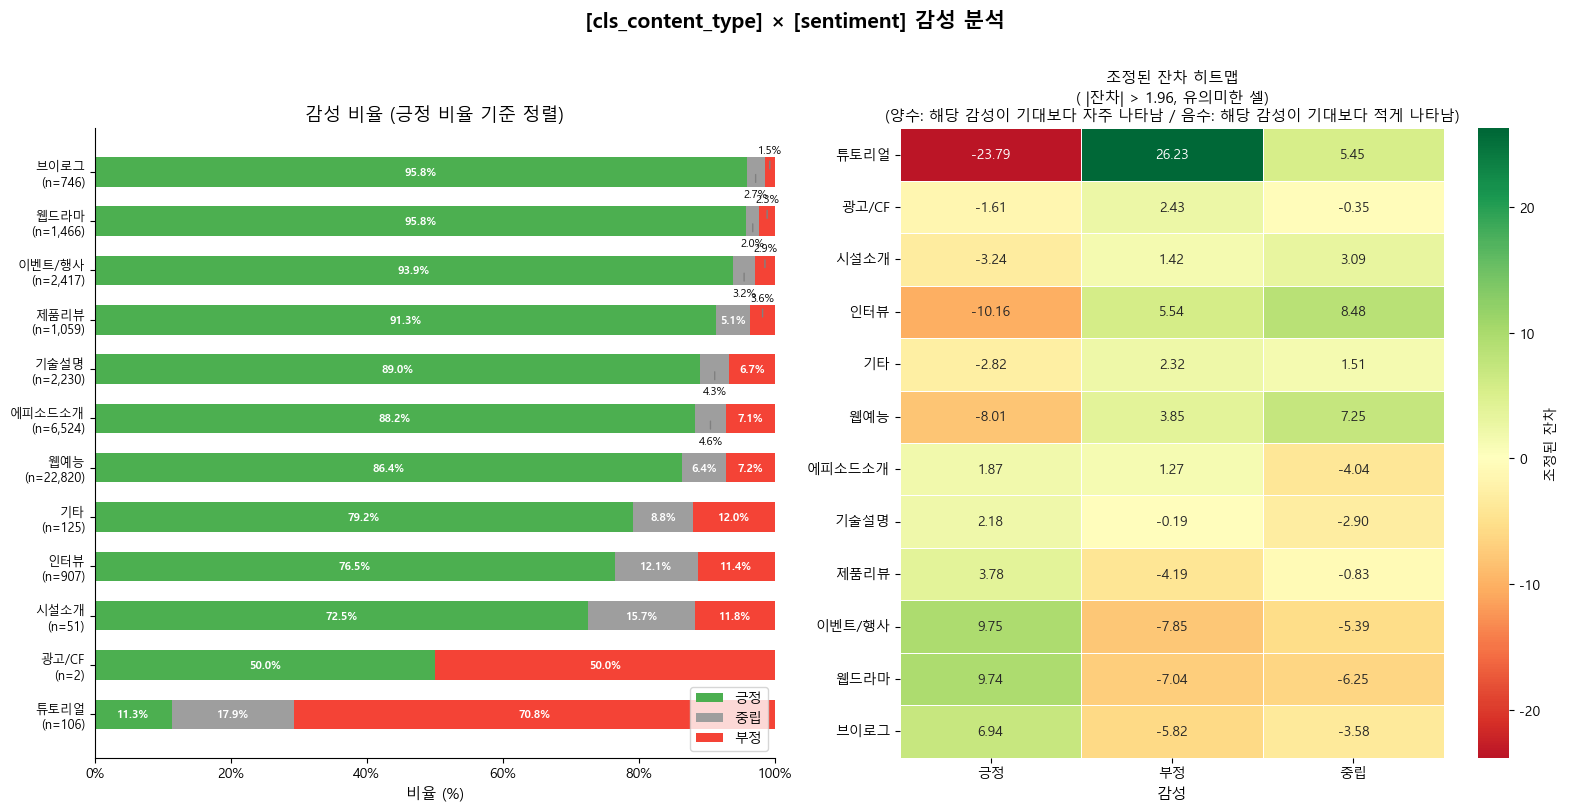

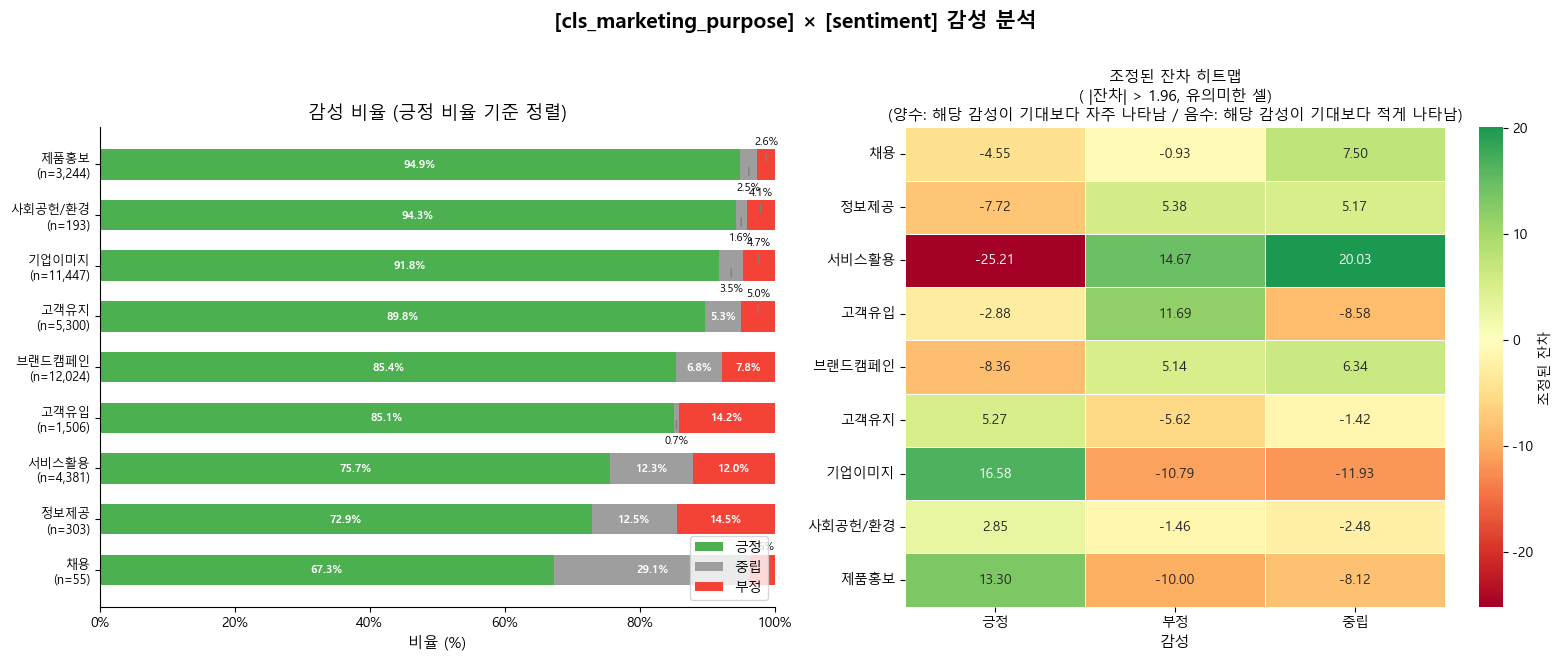

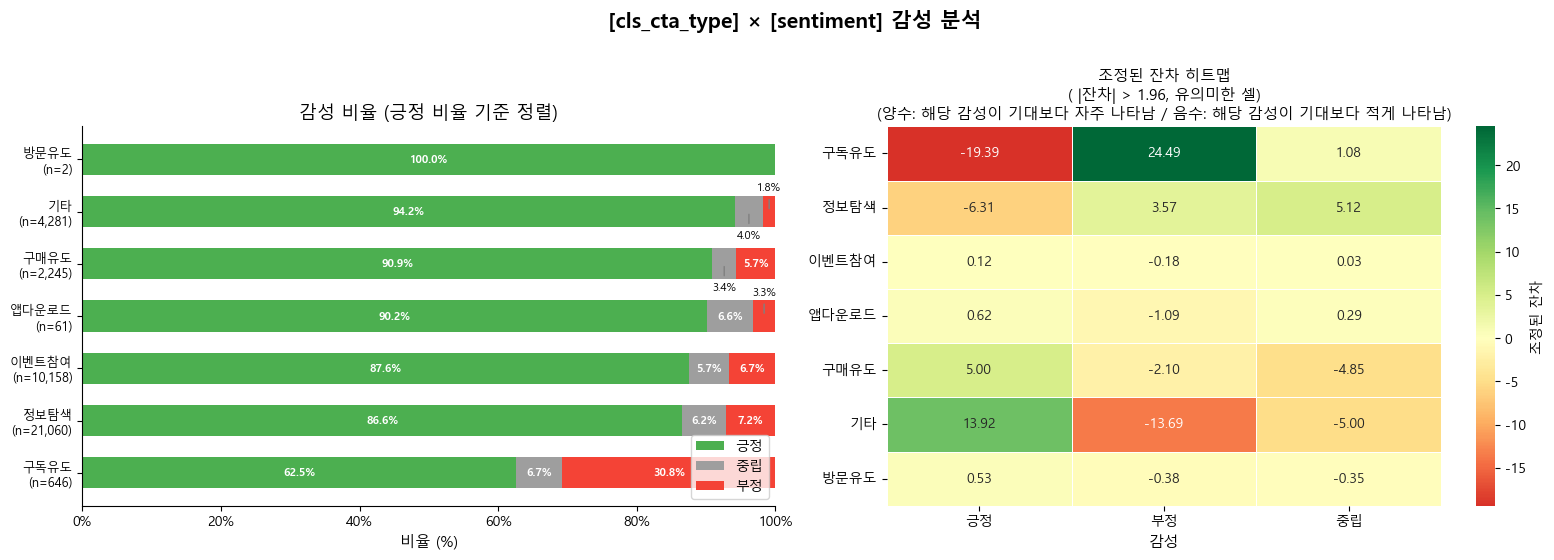

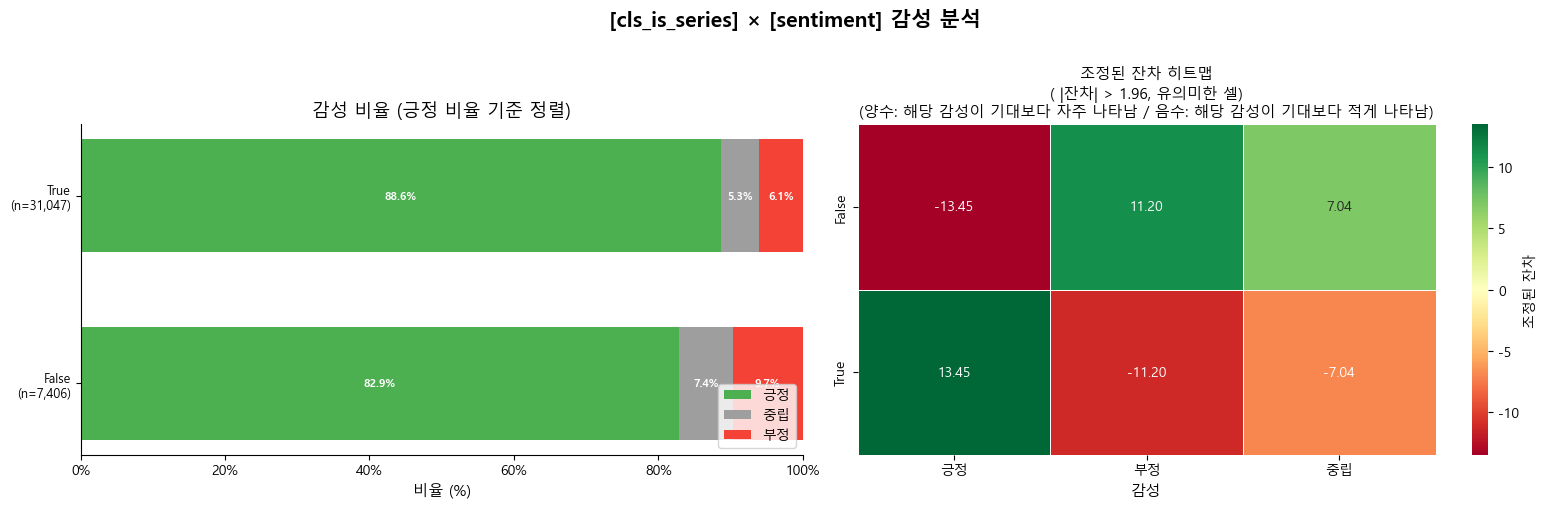

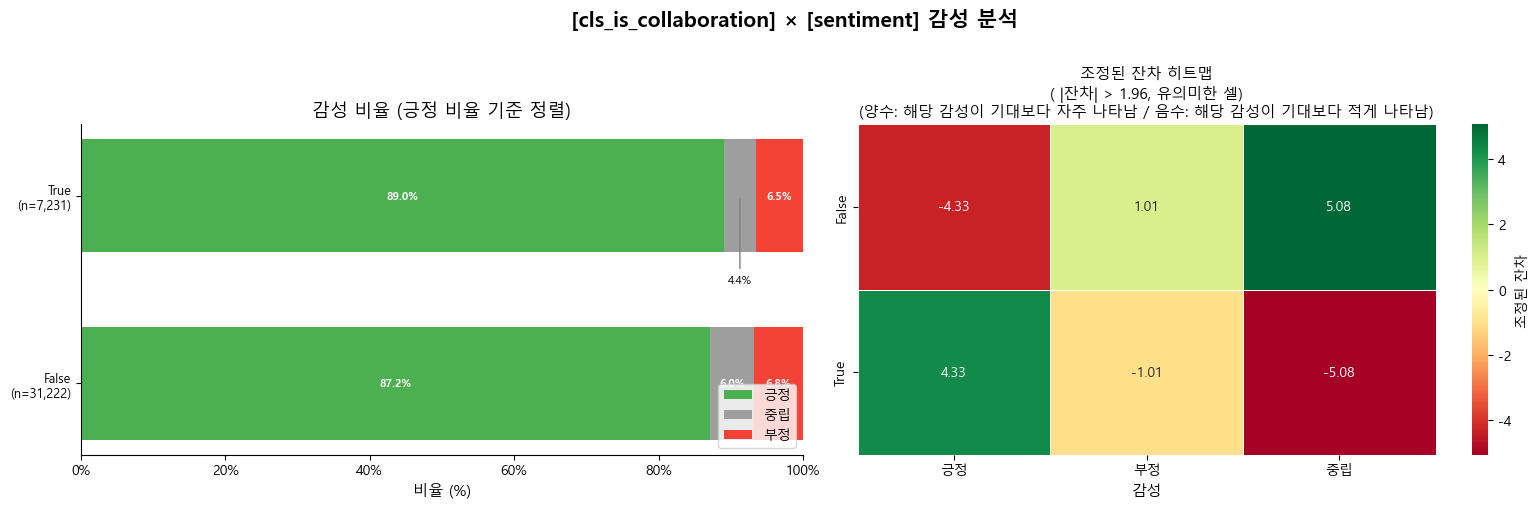

In [48]:
# ========================================
# 시각화 실행
# ========================================

# [역할] 카이제곱 검정 결과를 시각화
# [작업] 각 컬럼에 대해 visualize_chi2 함수 실행

for col in CATEGORICAL_COLS:
    visualize_chi2(df, col, results[col])
    plt.show()

---
### **두 가지 정보의 조합에서 댓글의 감성 분석하기 (1)**
- `content_type × is_series` 분석
    - is_series=True  → content_type별 긍정 비율 계산
    - is_series=False → content_type별 긍정 비율 계산
    - 각 content_type마다 시리즈일때의 긍정률 vs 시리즈가 아닐 때의 긍정률 비교
    - 시리즈가 유리한 콘텐츠 유형 / 시리즈로 제작하지 않는 것(단독)이 유리한 콘텐츠 유형 도출이 목표

In [49]:
# ========================================
# [분석] content_type × is_series 교차 분석
# ========================================

# [역할] 성공/실패 영상 각각에서, 시리즈 여부에 따라
#        콘텐츠 유형별 댓글 긍정 비율이 달라지는지 분석
# [근거] 성공/실패를 분리하여 분석함으로써
#        "어떤 콘텐츠 유형을 시리즈로 만들면 긍정 반응을 얻는지"를
#        성과 그룹별로 독립적으로 도출할 수 있음

def analyze_content_type_x_is_series(df_input, group_label):
    """
    특정 성과 그룹(성공 또는 실패) 내에서
    content_type × is_series 교차 분석을 수행하는 함수

    Parameters
    ----------
    df_input : 분석 대상 데이터프레임 (df_success 또는 df_fail)
    group_label: 출력 및 파일명에 사용할 레이블 (예: '성공', '실패')
    """

    print(f"\n{'='*60}")
    print(f"[{group_label} 영상] content_type × is_series 분석")
    print(f"{'='*60}")

    # ── 0. 분석용 컬럼 추출 ─────────────────────────────────────
    # [작업] 분석에 필요한 컬럼만 추출
    df_cross = df_input[['video_id', 'cls_content_type', 'cls_is_series', 'sentiment']].copy()

    print(f"\n[cls_is_series 분포]")
    print(df_cross['cls_is_series'].value_counts())
    print(f"\n[cls_content_type 분포]")
    print(df_cross['cls_content_type'].value_counts())

    # ── 1. 긍정 여부 컬럼 생성 ──────────────────────────────────
    # [작업] sentiment == '긍정'이면 1, 아니면 0
    df_cross['is_positive'] = (df_cross['sentiment'] == '긍정').astype(int)

    # ── 2. (cls_content_type × cls_is_series)별 긍정 비율 집계 ──
    agg = (
        df_cross.groupby(['cls_content_type', 'cls_is_series'])['is_positive']
        .agg(positive_count='sum', total='count')
        .reset_index()
    )
    agg['positive_ratio'] = agg['positive_count'] / agg['total']

    print(f"\n=== (콘텐츠 유형 × 시리즈 여부)별 긍정 비율 ===")
    display(agg.sort_values(['cls_content_type', 'cls_is_series']).reset_index(drop=True))

    # ── 3. 피벗: 시리즈 vs 단독 나란히 비교 ──────────────────────
    # [작업] cls_is_series를 컬럼으로 피벗
    # [주의] 한쪽 조건(시리즈/단독)이 없는 content_type은 NaN으로 남음
    pivot = agg.pivot_table(
        index='cls_content_type',
        columns='cls_is_series',  # 컬럼명이 cls_is_series의 고유값인 True/False로 생성됨
        values='positive_ratio'
    ).reset_index()
    
    pivot.columns.name = None

    pivot = pivot.rename(columns={
        True: '시리즈_긍정률',
        False: '단독_긍정률'
    })

    # [작업] 차이 계산 후 유리한 형식 판별
    # 차이(시리즈-단독) > 0 : 시리즈_긍정률 > 단독_긍정률 → 시리즈가 유리한 콘텐츠 유형
    # 차이(시리즈-단독) < 0 : 단독_긍정률 > 시리즈_긍정률 → 단독이 유리한 콘텐츠 유형
    # [참고] 최종 결론 테이블은 차이 기준 내림차순 정렬이므로
    #        표 위쪽(양수) = 시리즈 유리, 표 아래쪽(음수) = 단독 유리
    pivot['차이(시리즈-단독)'] = pivot['시리즈_긍정률'] - pivot['단독_긍정률']
    pivot['해석'] = pivot['차이(시리즈-단독)'].apply(
        lambda x: '🟢 시리즈물일 때, 유리함' if x > 0 else ('🔵 시리즈물이 아닐 때, 유리함' if x < 0 else '➖ 동일')
    )

    # ── 4. 통계 검정 (카이제곱 or Fisher's exact) ─────────────────
    # [작업] 각 content_type 내에서 is_series와 sentiment(긍정/비긍정) 간
    #        연관성이 통계적으로 유의한지 검정
    stat_results = []

    for ctype in df_cross['cls_content_type'].unique():
        sub = df_cross[df_cross['cls_content_type'] == ctype]
        ct = pd.crosstab(sub['is_positive'], sub['cls_is_series'])

        n_series = int(sub['cls_is_series'].sum())
        n_non_series = int((~sub['cls_is_series']).sum())

        # 한쪽 조건이 없으면 검정 불가
        if ct.shape != (2, 2):
            stat_results.append({
                'content_type':  ctype,
                'n_series': n_series, # 시리즈물인 영상의 개수
                'n_non_series':  n_non_series, # 시리즈물이 아닌 영상의 개수
                'p_value': float('nan'),
                'effect_size(φ)': float('nan'),
                'test':'skip(한쪽조건없음)',
                'significant':   False
            })
            continue
        
        # 시리즈/단독 각각 최소 30개 미만이면 검정 불가
        # 이유: 샘플이 너무 작으면 p값이 유의해도 신뢰하기 어려움
        if n_series < 30 or n_non_series < 30:
            stat_results.append({
                'content_type':  ctype,
                'n_series': n_series,
                'n_non_series':  n_non_series,
                'p_value': float('nan'),
                'effect_size(φ)': float('nan'),
                'test':'skip(샘플부족)',
                'significant':   False
            })
            continue

        # 카이제곱으로 기대빈도를 먼저 계산하여 검정 방법을 결정
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            chi2, p, dof, expected = chi2_contingency(ct)

        if (expected < 5).any():
            # 기대빈도 < 5인 셀이 있으면 Fisher's exact로 교체
            # 이유: 샘플이 작을 때 카이제곱 근사값이 부정확해지므로
            #       정확한 확률을 직접 계산하는 Fisher's exact를 사용
            _, p = fisher_exact(ct)
            test_name = "Fisher's exact"
        else:
            test_name = "Chi-square"

        # 효과크기: 파이 계수(φ) 계산
        # φ = sqrt(χ² / n) → 2×2 표에서 두 범주형 변수 간 연관성의 강도
        # 한 가지 콘텐츠 유형마다 통계 검정을 수행하고 있기 때문에 2×2 표가 맞음
        # 해석 기준(Cohen's w): 0.1 미만(매우 작은 효과), 0.1~0.3(작은 효과), 0.3~0.5(중간 효과), 0.5 이상(큰 효과)
        n_total = sub['cls_is_series'].count()
        phi = round(np.sqrt(chi2 / n_total), 4)

        stat_results.append({
            'content_type': ctype,
            'n_series': n_series, # 시리즈물인 영상의 개수
            'n_non_series': n_non_series, # 시리즈물이 아닌 영상의 개수
            'p_value': round(p, 4),
            'effect_size(φ)': phi,
            'test': test_name,
            'significant': p < 0.05 # 통계적 유의성 
        })

    stat_df = pd.DataFrame(stat_results).sort_values('p_value')
    print(f"\n=== 통계 검정 결과 ===")
    display(stat_df.reset_index(drop=True))

    # ── 5. 최종 결론 테이블 ──────────────────────────────────────
    # [작업] 긍정률 피벗 + 검정 결과 합치기
    # [근거] 통계적으로 유의하지 않은 차이는 결론으로 채택하지 않음
    df_final = pivot.merge(
        stat_df[['content_type', 'p_value', 'effect_size(φ)', 'significant', 'test']],
        left_on='cls_content_type',
        right_on='content_type',
        how='left'
    ).drop(columns='content_type')

    df_final['결론'] = df_final.apply(
        lambda row: row['해석'] if row['significant'] else '⚠️ 통계적으로 유의하지 않음',
        axis=1
    )

    print(f"\n=== [{group_label}] 최종 분석 결론 ===")
    display(
        df_final[[
            'cls_content_type', '시리즈_긍정률', '단독_긍정률',
            '차이(시리즈-단독)', 'p_value', 'effect_size(φ)', '결론'
        ]]
        .sort_values('차이(시리즈-단독)', ascending=False)
        .reset_index(drop=True)
    )

    # ── 6. 시각화 ────────────────────────────────────────────────
    # 샘플 부족 또는 한쪽 조건 없음으로 skip된 항목은 그래프에서도 제외
    valid_types = stat_df[stat_df['significant'] | (stat_df['p_value'].notna())]['content_type'].tolist()
    plot_df = (
        df_final[df_final['cls_content_type'].isin(valid_types)]
        .set_index('cls_content_type')[['시리즈_긍정률', '단독_긍정률']]
        .dropna()
    )

    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(plot_df))
    width = 0.35

    ax.bar(x - width/2, plot_df['시리즈_긍정률'], width, label='시리즈', color='#4C72B0', alpha=0.85)
    ax.bar(x + width/2, plot_df['단독_긍정률'],   width, label='단독',   color='#DD8452', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=25, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('긍정 댓글 비율')
    ax.set_title(f'[{group_label} 영상] 콘텐츠 유형별 시리즈 vs 단독 긍정 댓글 비율', fontsize=12)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return df_final


[성공 영상] content_type × is_series 분석

[cls_is_series 분포]
cls_is_series
True     31047
False     7406
Name: count, dtype: int64

[cls_content_type 분포]
cls_content_type
웹예능       22820
에피소드소개     6524
이벤트/행사     2417
기술설명       2230
웹드라마       1466
제품리뷰       1059
인터뷰         907
브이로그        746
기타          125
튜토리얼        106
시설소개         51
광고/CF         2
Name: count, dtype: int64

=== (콘텐츠 유형 × 시리즈 여부)별 긍정 비율 ===


,cls_content_type,cls_is_series,positive_count,total,positive_ratio
0,광고/CF,False,1,2,0.500000
1,기술설명,False,186,314,0.592357
2,기술설명,True,1799,1916,0.938935
3,기타,False,49,63,0.777778
4,기타,True,50,62,0.806452
5,브이로그,False,348,371,0.938005
6,브이로그,True,367,375,0.978667
7,시설소개,False,26,36,0.722222
8,시설소개,True,11,15,0.733333
9,에피소드소개,False,913,1272,0.717767



=== 통계 검정 결과 ===


,content_type,n_series,n_non_series,p_value,effect_size(φ),test,significant
0,웹예능,21082,1738,0.0000,0.0513,Chi-square,True
1,기술설명,1916,314,0.0000,0.3834,Chi-square,True
2,에피소드소개,5252,1272,0.0000,0.2506,Chi-square,True
3,브이로그,375,371,0.0094,0.0952,Chi-square,True
4,인터뷰,582,325,0.7221,0.0118,Chi-square,False
5,제품리뷰,292,767,0.8323,0.0065,Chi-square,False
6,기타,62,63,0.8614,0.0156,Chi-square,False
7,시설소개,15,36,NaN,NaN,skip(샘플부족),False
8,웹드라마,1462,4,NaN,NaN,skip(샘플부족),False
9,이벤트/행사,9,2408,NaN,NaN,skip(샘플부족),False



=== [성공] 최종 분석 결론 ===


,cls_content_type,시리즈_긍정률,단독_긍정률,차이(시리즈-단독),p_value,effect_size(φ),결론
0,기술설명,0.938935,0.592357,0.346579,0.0000,0.3834,"🟢 시리즈물일 때, 유리함"
1,에피소드소개,0.922125,0.717767,0.204358,0.0000,0.2506,"🟢 시리즈물일 때, 유리함"
2,웹예능,0.869225,0.802647,0.066578,0.0000,0.0513,"🟢 시리즈물일 때, 유리함"
3,이벤트/행사,1.000000,0.938538,0.061462,NaN,NaN,⚠️ 통계적으로 유의하지 않음
4,브이로그,0.978667,0.938005,0.040661,0.0094,0.0952,"🟢 시리즈물일 때, 유리함"
5,기타,0.806452,0.777778,0.028674,0.8614,0.0156,⚠️ 통계적으로 유의하지 않음
6,인터뷰,0.769759,0.756923,0.012836,0.7221,0.0118,⚠️ 통계적으로 유의하지 않음
7,시설소개,0.733333,0.722222,0.011111,NaN,NaN,⚠️ 통계적으로 유의하지 않음
8,제품리뷰,0.917808,0.911343,0.006465,0.8323,0.0065,⚠️ 통계적으로 유의하지 않음
9,웹드라마,0.957592,1.000000,-0.042408,NaN,NaN,⚠️ 통계적으로 유의하지 않음


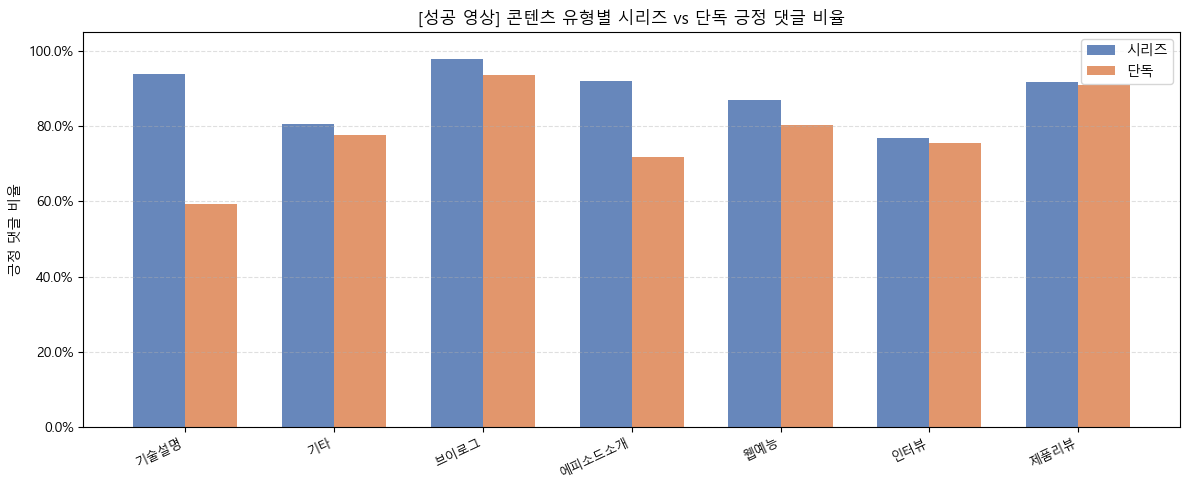

In [50]:
# 함수 실행
final_it_success_series = analyze_content_type_x_is_series(df, '성공')

---
### **두 가지 정보의 조합에서 댓글의 감성 분석하기 (2)**
- `content_type × is_collaboration` 분석
    - is_collaboration=True → content_type별 긍정 비율 계산
    - is_collaboration=False → content_type별 긍정 비율 계산
    - 어떤 콘텐츠 유형에서 콜라보한 영상이 긍정적인 반응을 이끌어내기에 유리한지, 
    또 어떤 콘텐츠 유형에서 콜라보하지 않은 영상이 유리한지 확인하는 것이 목표임 

In [51]:
# ========================================
# [분석] content_type × is_collaboration 교차 분석
# ========================================

# [역할] 성공/실패 영상 각각에서, 콜라보 여부에 따라
#        콘텐츠 유형별 댓글 긍정 비율이 달라지는지 분석
# [근거] 성공/실패를 분리하여 분석함으로써
#        "어떤 콘텐츠 유형을 콜라보로 만들면 긍정 반응을 얻는지"를
#        성과 그룹별로 독립적으로 도출할 수 있음

def analyze_content_type_x_is_collaboration(df_input, group_label):
    """
    특정 성과 그룹(성공 또는 실패) 내에서
    content_type × is_collaboration 교차 분석을 수행하는 함수

    Parameters
    ----------
    df_input   : 분석 대상 데이터프레임 (df_success 또는 df_fail)
    group_label: 출력 및 파일명에 사용할 레이블 (예: '성공', '실패')
    """

    print(f"\n{'='*60}")
    print(f"[{group_label} 영상] content_type × is_collaboration 분석")
    print(f"{'='*60}")

    # ── 0. 분석용 컬럼 추출 ─────────────────────────────────────
    # [작업] 분석에 필요한 컬럼만 추출
    df_cross = df_input[['video_id', 'cls_content_type', 'cls_is_collaboration', 'sentiment']].copy()

    print(f"\n[cls_is_collaboration 분포]")
    print(df_cross['cls_is_collaboration'].value_counts())
    print(f"\n[cls_content_type 분포]")
    print(df_cross['cls_content_type'].value_counts())

    # ── 1. 긍정 여부 컬럼 생성 ──────────────────────────────────
    # [작업] sentiment == '긍정'이면 1, 아니면 0
    df_cross['is_positive'] = (df_cross['sentiment'] == '긍정').astype(int)

    # ── 2. (cls_content_type × cls_is_collaboration)별 긍정 비율 집계 ──
    agg = (
        df_cross.groupby(['cls_content_type', 'cls_is_collaboration'])['is_positive']
        .agg(positive_count='sum', total='count')
        .reset_index()
    )
    agg['positive_ratio'] = agg['positive_count'] / agg['total']

    print(f"\n=== (콘텐츠 유형 × 콜라보 여부)별 긍정 비율 ===")
    display(agg.sort_values(['cls_content_type', 'cls_is_collaboration']).reset_index(drop=True))

    # ── 3. 피벗: 콜라보 vs 단독 나란히 비교 ──────────────────────
    # [작업] cls_is_collaboration을 컬럼으로 피벗
    # [주의] 한쪽 조건(콜라보/단독)이 없는 content_type은 NaN으로 남음
    pivot = agg.pivot_table(
        index='cls_content_type',
        columns='cls_is_collaboration',  # 컬럼명이 cls_is_collaboration의 고유값인 True/False로 생성됨
        values='positive_ratio'
    ).reset_index()

    pivot.columns.name = None

    pivot = pivot.rename(columns={
        True:  '콜라보_긍정률',
        False: '단독_긍정률'
    })

    # [작업] 차이 계산 후 유리한 형식 판별
    # 차이(콜라보-단독) > 0 : 콜라보_긍정률 > 단독_긍정률 → 콜라보가 유리한 콘텐츠 유형
    # 차이(콜라보-단독) < 0 : 단독_긍정률 > 콜라보_긍정률 → 단독이 유리한 콘텐츠 유형
    # [참고] 최종 결론 테이블은 차이 기준 내림차순 정렬이므로
    #        표 위쪽(양수) = 콜라보 유리, 표 아래쪽(음수) = 단독 유리
    pivot['차이(콜라보-단독)'] = pivot['콜라보_긍정률'] - pivot['단독_긍정률']
    pivot['해석'] = pivot['차이(콜라보-단독)'].apply(
        lambda x: '🟢 콜라보일 때, 유리함' if x > 0 else ('🔵 콜라보하지 않을 때, 유리함' if x < 0 else '➖ 동일')
    )

    # ── 4. 통계 검정 (카이제곱 or Fisher's exact) ─────────────────
    # [작업] 각 content_type 내에서 is_collaboration과 sentiment(긍정/비긍정) 간
    #        연관성이 통계적으로 유의한지 검정
    stat_results = []

    for ctype in df_cross['cls_content_type'].unique():
        sub = df_cross[df_cross['cls_content_type'] == ctype]
        ct = pd.crosstab(sub['is_positive'], sub['cls_is_collaboration'])

        n_collaboration     = int(sub['cls_is_collaboration'].sum())
        n_non_collaboration = int((~sub['cls_is_collaboration']).sum())

        # 한쪽 조건이 없으면 검정 불가
        if ct.shape != (2, 2):
            stat_results.append({
                'content_type':       ctype,
                'n_collaboration':     n_collaboration,     # 콜라보 영상의 댓글 수
                'n_non_collaboration': n_non_collaboration, # 단독 영상의 댓글 수
                'p_value':            float('nan'),
                'effect_size(φ)':     float('nan'),
                'test':               'skip(한쪽조건없음)',
                'significant':        False
            })
            continue

        # 콜라보/단독 각각 최소 30개 미만이면 검정 불가
        # 이유: 샘플이 너무 작으면 p값이 유의해도 신뢰하기 어려움
        if n_collaboration < 30 or n_non_collaboration < 30:
            stat_results.append({
                'content_type':       ctype,
                'n_collaboration':     n_collaboration,
                'n_non_collaboration': n_non_collaboration,
                'p_value':            float('nan'),
                'effect_size(φ)':     float('nan'),
                'test':               'skip(샘플부족)',
                'significant':        False
            })
            continue

        # 카이제곱으로 기대빈도를 먼저 계산하여 검정 방법을 결정
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            chi2, p, dof, expected = chi2_contingency(ct)

        if (expected < 5).any():
            # 기대빈도 < 5인 셀이 있으면 Fisher's exact로 교체
            # 이유: 샘플이 작을 때 카이제곱 근사값이 부정확해지므로
            #       정확한 확률을 직접 계산하는 Fisher's exact를 사용
            _, p = fisher_exact(ct)
            test_name = "Fisher's exact"
        else:
            test_name = "Chi-square"

        # 효과크기: 파이 계수(φ) 계산
        # φ = sqrt(χ² / n) → 2×2 표에서 두 범주형 변수 간 연관성의 강도
        # 한 가지 콘텐츠 유형마다 통계 검정을 수행하고 있기 때문에 2×2 표가 맞음
        # 해석 기준(Cohen's w): 0.1 미만(매우 작은 효과), 0.1~0.3(작은 효과), 0.3~0.5(중간 효과), 0.5 이상(큰 효과)
        n_total = sub['cls_is_collaboration'].count()
        phi = round(np.sqrt(chi2 / n_total), 4)

        stat_results.append({
            'content_type':       ctype,
            'n_collaboration':     n_collaboration,     # 콜라보 영상의 댓글 수
            'n_non_collaboration': n_non_collaboration, # 단독 영상의 댓글 수
            'p_value':            round(p, 4),
            'effect_size(φ)':     phi,
            'test':               test_name,
            'significant':        p < 0.05             # 통계적 유의성
        })

    stat_df = pd.DataFrame(stat_results).sort_values('p_value')
    print(f"\n=== 통계 검정 결과 ===")
    display(stat_df.reset_index(drop=True))

    # ── 5. 최종 결론 테이블 ──────────────────────────────────────
    # [작업] 긍정률 피벗 + 검정 결과 합치기
    # [근거] 통계적으로 유의하지 않은 차이는 결론으로 채택하지 않음
    df_final = pivot.merge(
        stat_df[['content_type', 'p_value', 'effect_size(φ)', 'significant', 'test']],
        left_on='cls_content_type',
        right_on='content_type',
        how='left'
    ).drop(columns='content_type')

    df_final['결론'] = df_final.apply(
        lambda row: row['해석'] if row['significant'] else '⚠️ 통계적으로 유의하지 않음',
        axis=1
    )

    print(f"\n=== [{group_label}] 최종 분석 결론 ===")
    display(
        df_final[[
            'cls_content_type', '콜라보_긍정률', '단독_긍정률',
            '차이(콜라보-단독)', 'p_value', 'effect_size(φ)', '결론'
        ]]
        .sort_values('차이(콜라보-단독)', ascending=False)
        .reset_index(drop=True)
    )

    # ── 6. 시각화 ────────────────────────────────────────────────
    # 샘플 부족 또는 한쪽 조건 없음으로 skip된 항목은 그래프에서도 제외
    valid_types = stat_df[stat_df['significant'] | (stat_df['p_value'].notna())]['content_type'].tolist()
    plot_df = (
        df_final[df_final['cls_content_type'].isin(valid_types)]
        .set_index('cls_content_type')[['콜라보_긍정률', '단독_긍정률']]
        .dropna()
    )

    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(plot_df))
    width = 0.35

    ax.bar(x - width/2, plot_df['콜라보_긍정률'], width, label='콜라보', color='#4C72B0', alpha=0.85)
    ax.bar(x + width/2, plot_df['단독_긍정률'],   width, label='단독',   color='#DD8452', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=25, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('긍정 댓글 비율')
    ax.set_title(f'[{group_label} 영상] 콘텐츠 유형별 콜라보 vs 단독 긍정 댓글 비율', fontsize=12)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return df_final


[성공 영상] content_type × is_collaboration 분석

[cls_is_collaboration 분포]
cls_is_collaboration
False    31222
True      7231
Name: count, dtype: int64

[cls_content_type 분포]
cls_content_type
웹예능       22820
에피소드소개     6524
이벤트/행사     2417
기술설명       2230
웹드라마       1466
제품리뷰       1059
인터뷰         907
브이로그        746
기타          125
튜토리얼        106
시설소개         51
광고/CF         2
Name: count, dtype: int64

=== (콘텐츠 유형 × 콜라보 여부)별 긍정 비율 ===


,cls_content_type,cls_is_collaboration,positive_count,total,positive_ratio
0,광고/CF,False,1,2,0.500000
1,기술설명,False,260,427,0.608899
2,기술설명,True,1725,1803,0.956739
3,기타,False,99,125,0.792000
4,브이로그,False,659,685,0.962044
5,브이로그,True,56,61,0.918033
6,시설소개,False,31,44,0.704545
7,시설소개,True,6,7,0.857143
8,에피소드소개,False,4306,4818,0.893732
9,에피소드소개,True,1450,1706,0.849941



=== 통계 검정 결과 ===


,content_type,n_collaboration,n_non_collaboration,p_value,effect_size(φ),test,significant
0,기술설명,1803,427,0.0000,0.4358,Chi-square,True
1,에피소드소개,1706,4818,0.0000,0.0592,Chi-square,True
2,이벤트/행사,149,2268,0.0000,0.1677,Chi-square,True
3,제품리뷰,350,709,0.0001,0.1205,Chi-square,True
4,웹드라마,100,1366,0.0023,0.0843,Fisher's exact,True
5,웹예능,3027,19793,0.0709,0.0120,Chi-square,False
6,브이로그,61,685,0.1004,0.0482,Fisher's exact,False
7,시설소개,7,44,NaN,NaN,skip(샘플부족),False
8,인터뷰,28,879,NaN,NaN,skip(샘플부족),False
9,튜토리얼,0,106,NaN,NaN,skip(한쪽조건없음),False



=== [성공] 최종 분석 결론 ===


,cls_content_type,콜라보_긍정률,단독_긍정률,차이(콜라보-단독),p_value,effect_size(φ),결론
0,기술설명,0.956739,0.608899,0.347839,0.0000,0.4358,"🟢 콜라보일 때, 유리함"
1,시설소개,0.857143,0.704545,0.152597,NaN,NaN,⚠️ 통계적으로 유의하지 않음
2,제품리뷰,0.962857,0.888575,0.074282,0.0001,0.1205,"🟢 콜라보일 때, 유리함"
3,웹예능,0.874794,0.862527,0.012266,0.0709,0.0120,⚠️ 통계적으로 유의하지 않음
4,에피소드소개,0.849941,0.893732,-0.043790,0.0000,0.0592,"🔵 콜라보하지 않을 때, 유리함"
5,브이로그,0.918033,0.962044,-0.044011,0.1004,0.0482,⚠️ 통계적으로 유의하지 않음
6,웹드라마,0.890000,0.962665,-0.072665,0.0023,0.0843,"🔵 콜라보하지 않을 때, 유리함"
7,이벤트/행사,0.778523,0.949295,-0.170771,0.0000,0.1677,"🔵 콜라보하지 않을 때, 유리함"
8,인터뷰,0.428571,0.775882,-0.347310,NaN,NaN,⚠️ 통계적으로 유의하지 않음
9,광고/CF,NaN,0.500000,NaN,NaN,NaN,⚠️ 통계적으로 유의하지 않음


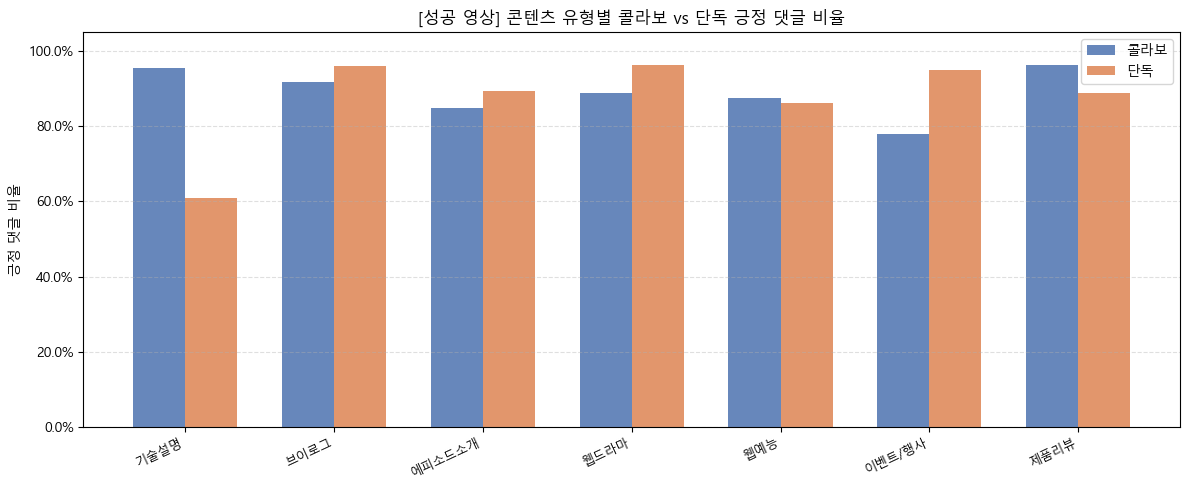

In [52]:
# 함수 실행
final_success_collaboration = analyze_content_type_x_is_collaboration(df, '성공')

---
### **두 가지 정보의 조합에서 댓글의 감성 분석하기 (3)**
- `content_type × marketing_purpose` 분석
    - 영상 업로드 목적(marketing_purpose)에 따라 어떤 유형의 영상을 제작하는 것이
    시청자의 긍정적인 반응을 이끌어내기에 유리한지 확인하는 것이 목표임

In [55]:
# ================================================
# [분석] content_type × marketing_purpose 교차 분석
# ================================================

# [역할] 성공/실패 영상 각각에서, 마케팅 목적과 콘텐츠 유형의 조합이
#        댓글 긍정 비율에 미치는 영향을 분석
# [근거] 두 범주형 변수 간 전체 연관성을 카이제곱으로 검정하고,
#        조합별 긍정률을 히트맵으로 시각화하여
#        긍정 반응을 이끌어내기에 유리한 조합을 도출

def analyze_content_type_x_marketing_purpose(df_input, group_label):
    """
    특정 성과 그룹(성공 또는 실패) 내에서
    content_type × marketing_purpose 교차 분석을 수행하는 함수

    Parameters
    ----------
    df_input   : 분석 대상 데이터프레임 (df_success 또는 df_fail)
    group_label: 출력 및 파일명에 사용할 레이블 (예: '성공', '실패')
    """

    print(f"\n{'='*60}")
    print(f"[{group_label} 영상] content_type × marketing_purpose 분석")
    print(f"{'='*60}")

    # ── 0. 분석용 컬럼 추출 ─────────────────────────────────────
    # [작업] 분석에 필요한 컬럼만 추출
    df_cross = df_input[['video_id', 'cls_content_type', 'cls_marketing_purpose', 'sentiment']].copy()

    print(f"\n[cls_marketing_purpose 분포]")
    print(df_cross['cls_marketing_purpose'].value_counts())
    print(f"\n[cls_content_type 분포]")
    print(df_cross['cls_content_type'].value_counts())

    # ── 1. 긍정 여부 컬럼 생성 ──────────────────────────────────
    # [작업] sentiment == '긍정'이면 1, 아니면 0
    df_cross['is_positive'] = (df_cross['sentiment'] == '긍정').astype(int)

    # ── 2. (cls_content_type × cls_marketing_purpose)별 긍정 비율 집계 ──
    agg = (
        df_cross.groupby(['cls_content_type', 'cls_marketing_purpose'])['is_positive']
        .agg(positive_count='sum', total='count')
        .reset_index()
    )
    agg['positive_ratio'] = agg['positive_count'] / agg['total']

    print(f"\n=== (콘텐츠 유형 × 마케팅 목적)별 긍정 비율 ===")
    display(agg.sort_values(['cls_content_type', 'cls_marketing_purpose']).reset_index(drop=True))

    # ── 3. 통계 검정: 전체 교차표 카이제곱 ───────────────────────
    # [작업] content_type × marketing_purpose 전체 교차표로 카이제곱 검정
    # [근거] marketing_purpose가 9개 범주라 개별 검정이 아닌
    #        전체 연관성을 한 번에 검정하는 방식을 사용
    # [주의] 댓글 수(total) 기준으로 교차표 생성
    #        → 각 셀: 해당 조합의 전체 댓글 수

    # 전체 교차표 생성 (행: content_type, 열: marketing_purpose, 값: 댓글 수)
    ct = pd.crosstab(df_cross['cls_content_type'], df_cross['cls_marketing_purpose'])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        chi2, p, dof, expected = chi2_contingency(ct)

    # 효과크기: Cramér's V 계산
    # [근거] 카이제곱은 표 크기에 따라 값이 달라지므로
    #        표 크기를 보정한 Cramér's V를 효과크기로 사용
    # 계산식: V = sqrt(χ² / (n × (min(행수, 열수) - 1)))
    # 해석 기준(Cohen): 0.1 미만(매우 작은 효과), 0.1~0.3(작은 효과),
    #                   0.3~0.5(중간 효과), 0.5 이상(큰 효과)
    n_total = df_cross.shape[0]
    min_dim = min(ct.shape) - 1
    cramers_v = round(np.sqrt(chi2 / (n_total * min_dim)), 4)

    print(f"\n=== 통계 검정 결과 ===")
    print(f"카이제곱 통계량 : {chi2:.4f}")
    print(f"p-value         : {p:.4f}")
    print(f"자유도          : {dof}")
    print(f"Cramér's V      : {cramers_v}")
    print(f"통계적 유의성   : {'유의함 (p < 0.05)' if p < 0.05 else '유의하지 않음 (p >= 0.05)'}")

    # ── 4. 피벗: 히트맵용 긍정률 테이블 생성 ─────────────────────
    # [작업] 행: content_type, 열: marketing_purpose, 값: positive_ratio
    # [주의] 댓글 수가 30개 미만인 셀은 NaN으로 처리하여 히트맵에서 제외
    #        → 샘플이 너무 작은 조합은 신뢰하기 어려움

    # 셀별 댓글 수 피벗 (30개 미만 필터링용)
    total_pivot = agg.pivot_table(
        index='cls_content_type',
        columns='cls_marketing_purpose',
        values='total'
    )

    # 긍정률 피벗
    ratio_pivot = agg.pivot_table(
        index='cls_content_type',
        columns='cls_marketing_purpose',
        values='positive_ratio'
    )

    # 댓글 수 30개 미만인 셀은 NaN으로 마스킹
    # [근거] 샘플이 너무 작으면 긍정률이 극단적으로 나올 수 있음
    ratio_pivot_masked = ratio_pivot.where(total_pivot >= 30)

    print(f"\n=== 조합별 긍정률 테이블 (댓글 수 30개 미만 셀은 NaN) ===")
    display(ratio_pivot_masked.round(4))

    # ── 5. 히트맵 시각화 ─────────────────────────────────────────
    # [작업] 조합별 긍정률을 히트맵으로 시각화
    # [근거] 수치 비교표보다 색상으로 패턴을 직관적으로 파악할 수 있음
    #        NaN 셀은 회색으로 표시 (데이터 부족)

    fig, ax = plt.subplots(figsize=(14, 7))

    # NaN 셀 위치 마스크 생성
    nan_mask = ratio_pivot_masked.isna()
    
    # 배경을 먼저 회색으로 깔기 (NaN 셀이 회색으로 보이도록)
    ax.set_facecolor('#D3D3D3')

    sns.heatmap(
        ratio_pivot_masked,
        annot=True,              # 셀 안에 수치 표시
        fmt='.2%',               # 퍼센트 형식
        cmap='RdYlGn',           # 빨강(낮음) → 노랑 → 초록(높음)
        vmin=0.7,                # 색상 범위 하한 (데이터에 따라 조정)
        vmax=1.0,                # 색상 범위 상한
        linewidths=0.5,
        linecolor='gray',
        mask=nan_mask,           # NaN 셀은 렌더링 제외 → 배경색(회색)이 드러남
        ax=ax,
        cbar_kws={'label': '긍정 댓글 비율'}
    )

    ax.set_title(
        f'[{group_label} 영상] 콘텐츠 유형 × 마케팅 목적별 긍정 댓글 비율\n'
        f'(Cramér\'s V={cramers_v}, p={p:.4f} / 회색=데이터 부족(30개 미만))',
        fontsize=12
    )
    ax.set_xlabel('마케팅 목적', fontsize=10)
    ax.set_ylabel('콘텐츠 유형', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    plt.tight_layout()
    plt.show()

    return ratio_pivot_masked


[성공 영상] content_type × marketing_purpose 분석

[cls_marketing_purpose 분포]
cls_marketing_purpose
브랜드캠페인     12024
기업이미지      11447
고객유지        5300
서비스활용       4381
제품홍보        3244
고객유입        1506
정보제공         303
사회공헌/환경      193
채용            55
Name: count, dtype: int64

[cls_content_type 분포]
cls_content_type
웹예능       22820
에피소드소개     6524
이벤트/행사     2417
기술설명       2230
웹드라마       1466
제품리뷰       1059
인터뷰         907
브이로그        746
기타          125
튜토리얼        106
시설소개         51
광고/CF         2
Name: count, dtype: int64

=== (콘텐츠 유형 × 마케팅 목적)별 긍정 비율 ===


,cls_content_type,cls_marketing_purpose,positive_count,total,positive_ratio
0,광고/CF,제품홍보,1,2,0.500000
1,기술설명,기업이미지,1867,2004,0.931637
2,기술설명,서비스활용,22,67,0.328358
3,기술설명,정보제공,94,157,0.598726
4,기술설명,제품홍보,2,2,1.000000
5,기타,기업이미지,27,32,0.843750
6,기타,브랜드캠페인,4,6,0.666667
7,기타,서비스활용,60,79,0.759494
8,기타,정보제공,8,8,1.000000
9,브이로그,기업이미지,487,510,0.954902



=== 통계 검정 결과 ===
카이제곱 통계량 : 50763.5524
p-value         : 0.0000
자유도          : 88
Cramér's V      : 0.4062
통계적 유의성   : 유의함 (p < 0.05)

=== 조합별 긍정률 테이블 (댓글 수 30개 미만 셀은 NaN) ===


cls_marketing_purpose,고객유입,고객유지,기업이미지,브랜드캠페인,사회공헌/환경,서비스활용,정보제공,제품홍보,채용
cls_content_type,,,,,,,,,
광고/CF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
기술설명,NaN,NaN,0.9316,NaN,NaN,0.3284,0.5987,NaN,NaN
기타,NaN,NaN,0.8438,NaN,NaN,0.7595,NaN,NaN,NaN
브이로그,NaN,NaN,0.9549,0.9565,1.0000,0.9552,NaN,NaN,NaN
시설소개,NaN,NaN,0.6905,NaN,NaN,NaN,NaN,NaN,NaN
에피소드소개,NaN,0.8158,0.9251,0.8313,NaN,0.4828,NaN,NaN,NaN
웹드라마,NaN,NaN,0.9608,0.8919,NaN,NaN,NaN,0.9200,NaN
웹예능,0.8513,0.8323,0.9797,0.8535,0.9896,0.8228,NaN,0.9525,NaN
이벤트/행사,NaN,0.9739,0.6375,NaN,NaN,NaN,NaN,NaN,NaN


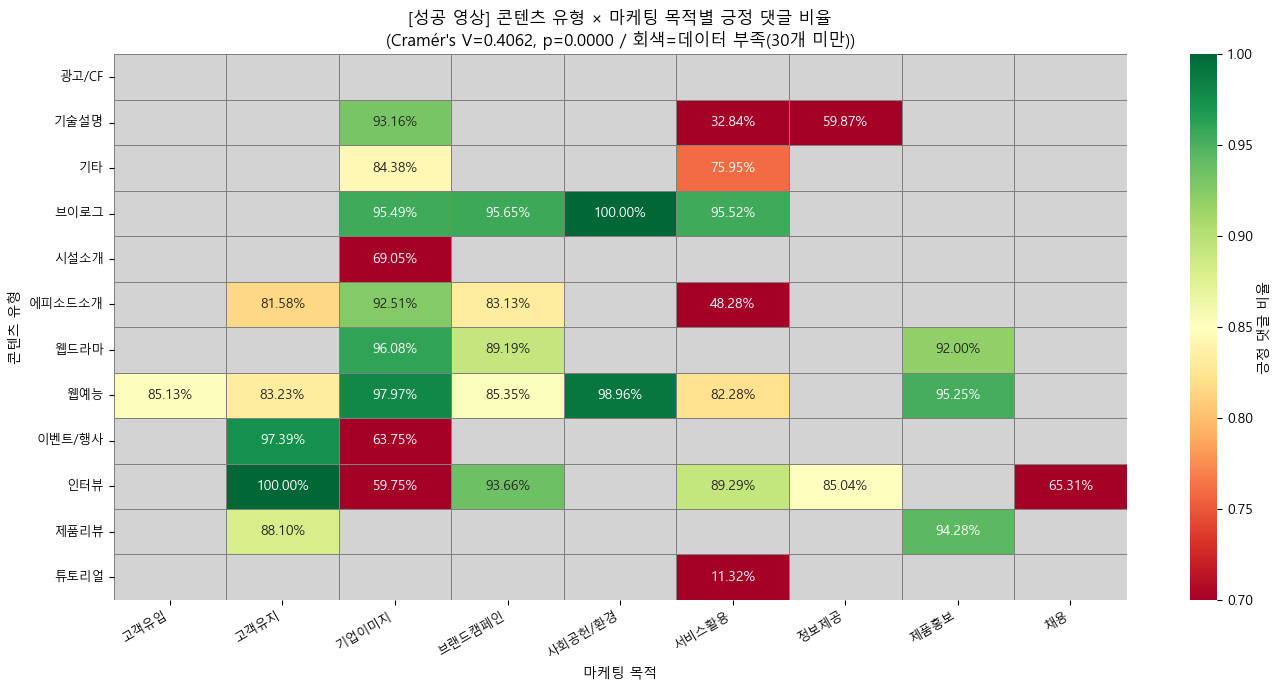

In [56]:
final_success_marketing = analyze_content_type_x_marketing_purpose(df, '성공')